# Calibrated seasonal rainfall outlook for Ethiopia — ONDJ 2026/27 walkthrough

**A training notebook: from raw ECMWF SEAS5 forecasts to a calibrated, mapped October–January (ONDJ) outlook**

This notebook follows, step by step, how the September-initialized ONDJ 2026/27 outlook was produced with the
project's scripts. Each section explains *what* the step does and *why*, shows the exact command, and then
inspects the real outputs with code, tables and figures.

| | |
| --- | --- |
| **Forecast system** | ECMWF SEAS5 (system 51), initialized 1 September 2026, 51 members |
| **Observations** | CHIRPS v2.0, 0.25°, reference seasons 1993/94–2024/25 (32 seasons) |
| **Targets** | ONDJ season and the months Oct, Nov, Dec, Jan |
| **Method** | Mean–variance amount correction → tercile counts → smoothing → climatology blend |
| **Status** | Research reconstruction — **not** an official EMI or ICPAC forecast |

**Learning objectives.** After working through the notebook you should be able to:
1. explain how a season that crosses the year boundary (ONDJ) is handled;
2. turn accumulated model precipitation into daily and seasonal totals and check them;
3. explain the calibration chain on a single grid cell, from raw members to final probabilities;
4. read historical skill (RPSS) critically, including significance;
5. reproduce the full run, and adapt it to another season.

Companion documents: `docs/37_NEW_FORECAST_CYCLE.md` (running a cycle) and `docs/38_REPRODUCIBLE_RUNBOOK.md`
(runbook, issue log, automation blueprint).

## Table of contents

1. [Setup](#s1)
2. [The forecast cycle and its configuration](#s2)
3. [Step 1 — Download ECMWF SEAS5](#s3)
4. [Step 2 — Inside a raw forecast file](#s4)
5. [Step 3 — Inventory of all inputs](#s5)
6. [Step 4 — Seasonal totals](#s6)
7. [Step 5 — Regridding 1° → 0.25°](#s7)
8. [Step 6 — Monthly targets and the reconstruction check](#s8)
9. [Step 7 — The ONDJ rainfall domain](#s9)
10. [Step 8 — Calibration explained on one grid cell](#s10)
11. [Step 9 — Historical skill](#s11)
12. [Step 10 — Final fit and the 2026/27 forecast](#s12)
13. [Step 11 — Forecast maps](#s13)
14. [Step 12 — Publishing](#s14)
15. [Issues met and lessons](#s15)
16. [Exercises](#s16)
17. [References](#s17)

<a id="s1"></a>
## 1. Setup

The notebook runs from the project's `notebooks/` folder with the project virtual environment
(`.venv`). It selects the ONDJ **cycle file** before importing any project module, because every
script reads the forecast year, reference period and folders from it.

Heavy steps (download, preparation, fitting) have already been run. They are shown as commands and
only re-run if you switch the flags below to `True`; by default the notebook **reads their outputs**.

In [1]:
import os, sys, json, subprocess
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(ROOT)
os.environ['CALIBRATION_CYCLE'] = 'config/cycles/sep_2026_ondj.json'   # must precede project imports
sys.path.insert(0, str(ROOT / 'scripts'))

RUN_DOWNLOAD = False   # ~1.5 h of CDS queue for 34 years
RUN_PIPELINE = False   # preparation, regridding, skill and fit (minutes; rewrites outputs)

def run(command, enabled):
    # Show a pipeline command, and execute it only when its flag is True.
    print('>', command)
    if enabled:
        result = subprocess.run(command, shell=True, cwd=ROOT, capture_output=True, text=True)
        print(result.stdout[-2000:], result.stderr[-2000:])
    else:
        print('  (not executed: outputs from the recorded run are used below)')

import numpy as np, pandas as pd, xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from IPython.display import Image, display, Markdown
pd.set_option('display.precision', 3)
print('Project root:', ROOT)

Project root: D:\calibrated_seasonal_rainfall


In [2]:
# Plot style: validated palette (blue / orange / aqua), one-hue sequential ramp, red-grey-blue diverging.
SURFACE, INK, INK2, GRID = '#fcfcfb', '#0b0b0b', '#52514e', '#e4e3df'
BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
SEQ = LinearSegmentedColormap.from_list('seq_blue', ['#cde2fb', '#86b6ef', '#3987e5', '#256abf', '#184f95', '#0d366b'])
DIV = LinearSegmentedColormap.from_list('div', ['#b3261e', '#e34948', '#f0efec', '#3987e5', '#184f95'])
plt.rcParams.update({'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
                     'text.color': INK, 'axes.labelcolor': INK2, 'xtick.color': INK2, 'ytick.color': INK2,
                     'axes.edgecolor': GRID, 'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': .6,
                     'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 10,
                     'axes.titlesize': 11, 'axes.titleweight': 'bold', 'lines.linewidth': 2, 'figure.dpi': 110})

def map_axes(ax, title):
    ax.set_title(title, loc='left'); ax.set_aspect('equal'); ax.grid(False)
    ax.set_xlabel('Longitude (°E)'); ax.set_ylabel('Latitude (°N)')

<a id="s2"></a>
## 2. The forecast cycle and its configuration

Three configuration layers drive every script:

* **Project config** (`config/ondj/project.json`) — the season, raw-data folders, archive and observation years.
* **Monthly configs** (`config/ondj/monthly_Oct.json` …) — created automatically for each month of the season.
* **Cycle file** (`config/cycles/sep_2026_ondj.json`) — one forecast issue: year, reference period, targets, output folders.

The key idea for ONDJ is the **season window**. A season starts in the initialization year if its start month is
on or after the initialization month, otherwise in the next year; it ends in the next year when its end month comes
before its start month. So ONDJ from September 2026 runs from **1 October 2026 to 31 January 2027**, and the
January target belongs to **2027**.

In [3]:
from cycle import CYCLE
from common import load_config, season_window, season_months
project = load_config('config/ondj/project.json')
print(json.dumps({k: project[k] for k in ['initialization_month', 'season', 'archive_years', 'observation_years',
                                          'ecmwf_directory', 'negative_increment_tolerance_mm']}, indent=1))
print('\nCycle:', CYCLE.path.name, '| forecast year', CYCLE.year, '| reference', CYCLE.reference_label,
      '| targets', CYCLE.targets)
pd.DataFrame([{'target': t, 'label': CYCLE.target_label(t)} for t in CYCLE.targets])

{
 "initialization_month": 9,
 "season": {
  "name": "ONDJ",
  "start": "10-01",
  "end": "01-31"
 },
 "archive_years": [
  1993,
  2026
 ],
 "observation_years": [
  1993,
  2024
 ],
 "ecmwf_directory": "data/raw/ecmwf/et_sep_init",
 "negative_increment_tolerance_mm": 0.2
}

Cycle: sep_2026_ondj.json | forecast year 2026 | reference 1993-2024 | targets ('Oct', 'Nov', 'Dec', 'Jan', 'ONDJ')


,target,label
0,Oct,Oct 2026
1,Nov,Nov 2026
2,Dec,Dec 2026
3,Jan,Jan 2027
4,ONDJ,ONDJ 2026/27


,target,start,end,days
0,Oct,2026-10-01,2026-10-31,31
1,Nov,2026-11-01,2026-11-30,30
2,Dec,2026-12-01,2026-12-31,31
3,Jan,2027-01-01,2027-01-31,31
4,ONDJ,2026-10-01,2027-01-31,123


ONDJ months: [10, 11, 12, 1]


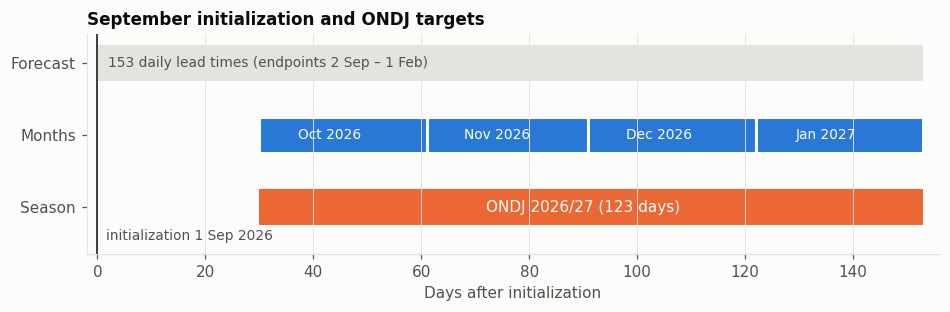

In [4]:
from run_monthly import monthly_config
import calendar
rows = []
for t in CYCLE.targets:
    cfg = project if t == 'ONDJ' else monthly_config(project, list(calendar.month_abbr).index(t))
    s, e = season_window(cfg, 2026)
    rows.append(dict(target=t, start=s, end=e, days=(e - s).days + 1))
window = pd.DataFrame(rows)
display(window)
print('ONDJ months:', season_months(project))

# Timeline: initialization, lead time and target periods
fig, ax = plt.subplots(figsize=(10, 2.6))
t0 = pd.Timestamp('2026-09-01'); end = pd.Timestamp('2027-02-01')
ax.barh(2, (end - t0).days, left=0, height=.5, color='#e4e3df')
ax.text(2, 2, '153 daily lead times (endpoints 2 Sep – 1 Feb)', va='center', color=INK2, fontsize=9)
for i, r in window[window.target != 'ONDJ'].iterrows():
    ax.barh(1, (pd.Timestamp(r.end) - pd.Timestamp(r.start)).days + 1, left=(pd.Timestamp(r.start) - t0).days,
            height=.5, color=BLUE, edgecolor=SURFACE, linewidth=2)
    ax.text((pd.Timestamp(r.start) - t0).days + 13, 1, CYCLE.target_label(r.target), va='center', ha='center',
            color='white', fontsize=9)
s = window[window.target == 'ONDJ'].iloc[0]
ax.barh(0, (pd.Timestamp(s.end) - pd.Timestamp(s.start)).days + 1, left=(pd.Timestamp(s.start) - t0).days,
        height=.5, color=ORANGE)
ax.text((pd.Timestamp(s.start) - t0).days + 60, 0, 'ONDJ 2026/27 (123 days)', va='center', ha='center', color='white')
ax.axvline(0, color=INK, lw=1); ax.text(1.5, -.45, 'initialization 1 Sep 2026', fontsize=9, color=INK2)
ax.set_yticks([0, 1, 2], ['Season', 'Months', 'Forecast']); ax.set_xlabel('Days after initialization')
ax.set_xlim(-2, 156); ax.set_ylim(-.65, 2.4); ax.grid(axis='y', visible=False); ax.set_title('September initialization and ONDJ targets', loc='left')
plt.show()

<a id="s3"></a>
## 3. Step 1 — Download ECMWF SEAS5

The downloader requests daily accumulated precipitation from the Copernicus Climate Data Store
(`seasonal-original-single-levels`) for each year. ONDJ needs lead times through the end of January:
Sep 30 + Oct 31 + Nov 30 + Dec 31 + Jan 31 = **153 days**.

* A `~/.cdsapirc` file with your CDS key is required.
* On Windows set `PYTHONIOENCODING=utf-8` first; the downloader prints a `→` that the default console cannot encode.
* The CDS queue is the slow part (about 1.5 hours for 34 years with three parallel batches).

In [5]:
run('set PYTHONIOENCODING=utf-8 && python scripts/download_seasonal_forecasts_daily_c3s.py --models ecmwf '
    '--system ecmwf=51 --variables total_precipitation --year-start 1993 --year-end 2026 --months 9 --init-day 1 '
    '--leadtime-days 153 --north 15 --west 33 --south 3 --east 48 --outdir data/raw/ecmwf/et_sep_init', RUN_DOWNLOAD)

files = sorted(Path('data/raw/ecmwf/et_sep_init').glob('ecmwf_*09_d01.nc'))
info = []
for f in files:
    with xr.open_dataset(f) as d:
        info.append(dict(year=int(f.name[6:10]), members=d.sizes['number'], lead_days=d.sizes['forecast_period'],
                         first_endpoint=str(d.valid_time.values[0])[:10], last_endpoint=str(d.valid_time.values[-1])[:10],
                         size_MB=round(f.stat().st_size / 1e6, 2)))
inventory = pd.DataFrame(info)
print(len(files), 'files')
display(inventory.iloc[[0, 1, 23, 24, -2, -1]])
print('Members per period:', inventory.groupby(inventory.year <= 2016).members.unique().to_dict())

> set PYTHONIOENCODING=utf-8 && python scripts/download_seasonal_forecasts_daily_c3s.py --models ecmwf --system ecmwf=51 --variables total_precipitation --year-start 1993 --year-end 2026 --months 9 --init-day 1 --leadtime-days 153 --north 15 --west 33 --south 3 --east 48 --outdir data/raw/ecmwf/et_sep_init
  (not executed: outputs from the recorded run are used below)


34 files


,year,members,lead_days,first_endpoint,last_endpoint,size_MB
0,1993,25,153,1993-09-02,1994-02-01,0.82
1,1994,25,153,1994-09-02,1995-02-01,0.86
23,2016,25,153,2016-09-02,2017-02-01,0.80
24,2017,51,153,2017-09-02,2018-02-01,1.61
32,2025,51,153,2025-09-02,2026-02-01,1.58
33,2026,51,153,2026-09-02,2027-02-01,1.68


Members per period: {False: array([51], dtype=int64), True: array([25], dtype=int64)}


<a id="s4"></a>
## 4. Step 2 — Inside a raw forecast file

The variable `tp` is **total precipitation in metres, accumulated since initialization**. Daily rainfall is the
difference between consecutive endpoints × 1000 (mm), labelled by the start of the interval. The figure shows
the 51 members at one grid cell in southern Ethiopia: accumulations (top) and the daily amounts derived from them
(bottom), with the ONDJ window shaded.

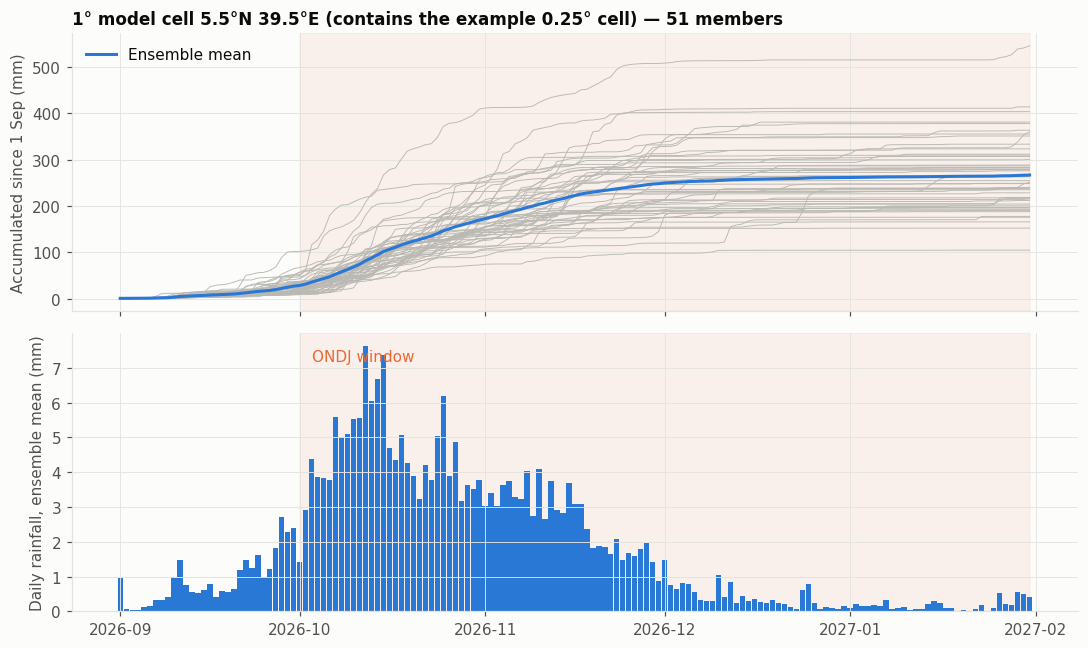

In [6]:
raw = xr.open_dataset('data/raw/ecmwf/et_sep_init/ecmwf_202609_d01.nc')
LAT, LON = 5.375, 39.375                 # example 0.25° cell (southern Ethiopia, inside the ONDJ rainfall domain)
cell = raw.tp.isel(forecast_reference_time=0).sel(latitude=LAT, longitude=LON, method='nearest') * 1000
dates = pd.DatetimeIndex(raw.valid_time.values) - pd.Timedelta(days=1)   # interval start labels
daily = cell.diff('forecast_period', label='upper')
daily = xr.concat([cell.isel(forecast_period=0), daily], 'forecast_period')

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for ax in axes:
    ax.axvspan(pd.Timestamp('2026-10-01'), pd.Timestamp('2027-01-31'), color=ORANGE, alpha=.08)
for m in range(cell.sizes['number']):
    axes[0].plot(dates, cell.isel(number=m), color='#b9b8b2', lw=.6)
axes[0].plot(dates, cell.mean('number'), color=BLUE, label='Ensemble mean')
axes[0].set_ylabel('Accumulated since 1 Sep (mm)')
axes[0].set_title(f'1° model cell {float(cell.latitude):.1f}°N {float(cell.longitude):.1f}°E (contains the example 0.25° cell) — 51 members', loc='left')
axes[0].legend(loc='upper left', frameon=False)
axes[1].bar(dates, daily.mean('number'), width=.9, color=BLUE)
axes[1].set_ylabel('Daily rainfall, ensemble mean (mm)')
axes[1].text(pd.Timestamp('2026-10-03'), axes[1].get_ylim()[1] * .9, 'ONDJ window', color=ORANGE)
plt.tight_layout(); plt.show()

**GRIB packing.** `tp` is stored with limited precision: each field is packed with a step that depends on its value
range: tiny for nearly dry fields, up to 0.122 mm (2⁻¹³ m) for the wettest. On dry days the accumulation can therefore
step *down* by a packing step. These are rounding, not negative rain. The project tolerates drops down to −0.2 mm,
checks that the seasonal sum still equals the endpoint difference, then clips them to zero.

1,395,360 daily increments; 5,450 negative (0.39%); largest drop -0.1224 mm = one 2^-13 m packing step (-0.1221 mm)


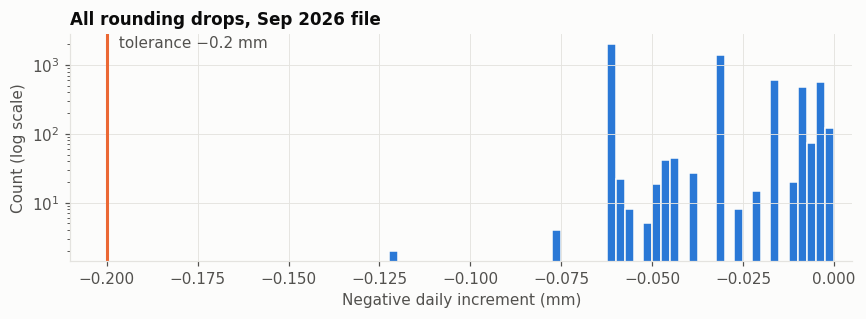

In [7]:
inc = raw.tp.isel(forecast_reference_time=0).diff('forecast_period').values.ravel() * 1000
neg = inc[inc < 0]
print(f'{inc.size:,} daily increments; {neg.size:,} negative ({100 * neg.size / inc.size:.2f}%); '
      f'largest drop {neg.min():.4f} mm = one 2^-13 m packing step ({-2**-13 * 1000:.4f} mm)')
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(neg, bins=np.arange(-0.2, 0.0001, 0.0025), color=BLUE, edgecolor=SURFACE, linewidth=1)
ax.axvline(-0.2, color=ORANGE, lw=2); ax.text(-0.198, ax.get_ylim()[1] * .85, ' tolerance −0.2 mm', color=INK2)
ax.set_xlim(-0.21, 0.005)
ax.set_yscale('log'); ax.set_xlabel('Negative daily increment (mm)'); ax.set_ylabel('Count (log scale)'); ax.set_title('All rounding drops, Sep 2026 file', loc='left')
plt.tight_layout(); plt.show()

<a id="s5"></a>
## 5. Step 3 — Inventory of all inputs

`inspect_inputs.py` opens every forecast file and checks the initialization date, lead coverage of the season,
member count (25 for 1993–2016 hindcasts, 51 from 2017) and a sample of increments, plus the CHIRPS archive dates.

In [8]:
run('python scripts/inspect_inputs.py --config config/ondj/project.json', RUN_PIPELINE)
inv = json.load(open('outputs/inspection/init09_ONDJ/inventory.json'))
table = pd.DataFrame(inv['ecmwf'])[['year', 'status', 'members', 'daily_date_first', 'daily_date_last']]
print('All years ok:', (table.status == 'ok').all(), '| CHIRPS:', inv['chirps']['status'],
      inv['chirps']['first'][:10], 'to', inv['chirps']['last'][:10])
table.head(3)

> python scripts/inspect_inputs.py --config config/ondj/project.json
  (not executed: outputs from the recorded run are used below)
All years ok: True | CHIRPS: ok 1993-01-01 to 2025-12-31


,year,status,members,daily_date_first,daily_date_last
0,1993,ok,25,1993-09-01 00:00:00,1994-01-31 00:00:00
1,1994,ok,25,1994-09-01 00:00:00,1995-01-31 00:00:00
2,1995,ok,25,1995-09-01 00:00:00,1996-01-31 00:00:00


<a id="s6"></a>
## 6. Step 4 — Seasonal totals

`prepare_seasonal.py` de-accumulates every member, selects the 123 ONDJ days of each year (crossing into
January of the next year), sums them, and builds the matching CHIRPS totals. Seasons with any missing
day stay missing. CHIRPS exists for seasons 1993/94–2024/25 because the archive ends in December 2025.

In [9]:
run('python scripts/prepare_seasonal.py --config config/ondj/project.json --all-years', RUN_PIPELINE)
qc = pd.DataFrame(json.load(open('outputs/qc/preparation_init09_ONDJ.json')))
print('years:', len(qc), '| days per season:', qc.days.unique(), '| missing fraction > 0:',
      list(qc[qc.missing_seasonal_fraction > 0].year), '| max clipping adjustment (mm):', round(qc.clipping_adjustment_max_mm.max(), 3))
print('Years without observations:', list(qc[qc.get('observations').notna()].year) if 'observations' in qc else [])
qc[['year', 'members', 'days', 'missing_seasonal_fraction', 'clipping_adjustment_max_mm']].tail(4)

> python scripts/prepare_seasonal.py --config config/ondj/project.json --all-years
  (not executed: outputs from the recorded run are used below)
years: 34 | days per season: [123] | missing fraction > 0: [] | max clipping adjustment (mm): 0.183
Years without observations: [2025, 2026]


,year,members,days,missing_seasonal_fraction,clipping_adjustment_max_mm
30,2023,51,123,0.0,0.122
31,2024,51,123,0.0,0.153
32,2025,51,123,0.0,0.171
33,2026,51,123,0.0,0.183


<a id="s7"></a>
## 7. Step 5 — Regridding 1° → 0.25°

ECMWF is on a 1° grid; CHIRPS is 0.25°. Their outer cell edges coincide (3–15°N, 33–48°E), so each 1° cell
maps exactly onto a 4×4 block of 0.25° cells. The regridder copies the value into the block and checks area
conservation. This adds **no** new information: the 0.25° map repeats the 1° model values.

> python scripts/regrid_seasonal.py --config config/ondj/project.json
  (not executed: outputs from the recorded run are used below)


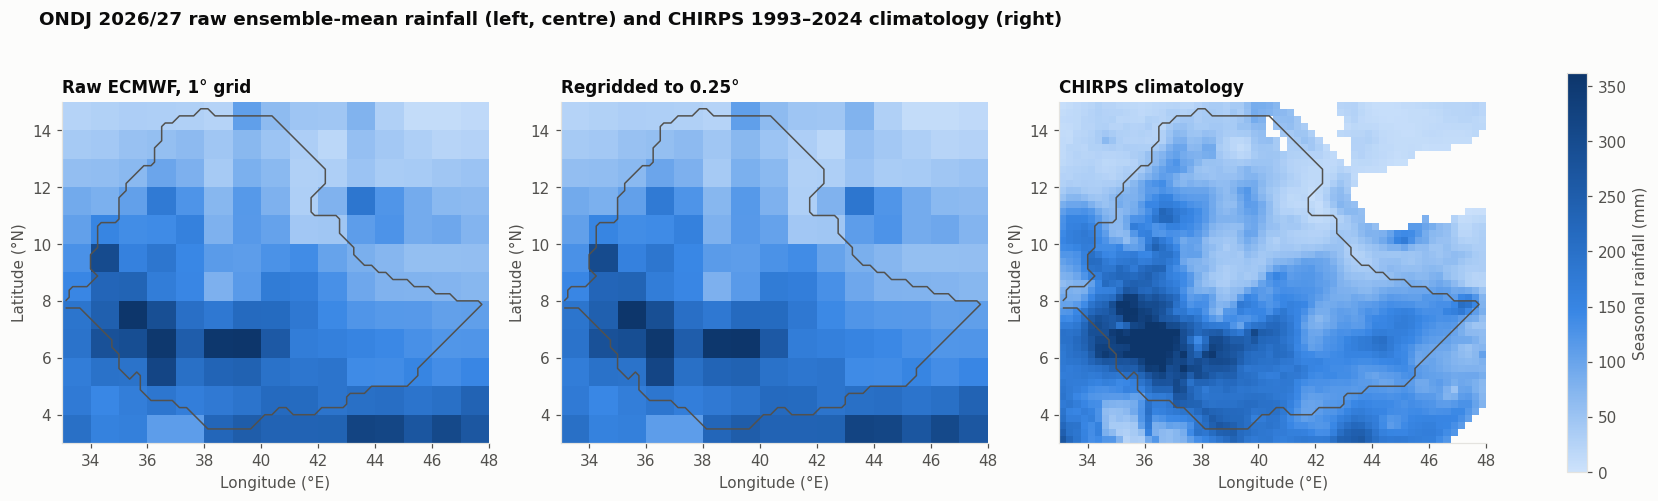

first-order conservative nested-grid remapping | years: 34 | max relative conservation error: 1.3e-14 | CHIRPS valid / sea cells: 2657 / 223


In [10]:
run('python scripts/regrid_seasonal.py --config config/ondj/project.json', RUN_PIPELINE)
native = xr.open_dataset('data/interim/init09_ONDJ/ecmwf_2026_native.nc').precip_season.mean('member')
common = xr.open_dataset('data/processed/init09_ONDJ/ecmwf_2026_common.nc').precip_season.mean('member')
obs = xr.open_dataset('data/masks/init09_ONDJ_rainfall_domain.nc').season_climatology_mm
vmax = float(np.nanpercentile(common, 99))
country = xr.open_dataset('data/masks/ethiopia_common.nc').region_mask
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), layout='constrained')
for ax, field, title in [(axes[0], native, 'Raw ECMWF, 1° grid'),
                         (axes[1], common, 'Regridded to 0.25°'),
                         (axes[2], obs, 'CHIRPS climatology')]:
    im = ax.pcolormesh(field.lon, field.lat, field, cmap=SEQ, vmin=0, vmax=vmax, shading='auto')
    ax.contour(country.lon, country.lat, country, levels=[.5], colors=[INK2], linewidths=1)
    map_axes(ax, title)
fig.suptitle('ONDJ 2026/27 raw ensemble-mean rainfall (left, centre) and CHIRPS 1993–2024 climatology (right)', x=.02, ha='left', fontweight='bold')
fig.colorbar(im, ax=axes, shrink=.85, label='Seasonal rainfall (mm)')
plt.show()
rq = json.load(open('outputs/qc/regridding_init09_ONDJ.json'))
print(rq['method'], '| years:', len(rq['years']), '| max relative conservation error:',
      f"{max(r['conservation_max_relative_error'] for r in rq['years']):.1e}",
      '| CHIRPS valid / sea cells:', rq['years'][0].get('observation_valid_cells'), '/', rq['years'][0].get('observation_missing_cells'))

<a id="s8"></a>
## 8. Step 6 — Monthly targets and the reconstruction check

`run_monthly.py` creates one config per month of the season and runs the same preparation and regridding for
Oct, Nov, Dec and Jan. A built-in check confirms that, for every year, the four monthly totals add up to the
ONDJ total (tolerance 0.001 mm + 10⁻⁶ × total).

In [11]:
run('python scripts/run_monthly.py --config config/ondj/project.json --stage prepare', RUN_PIPELINE)
rec = pd.DataFrame(json.load(open('outputs/qc/monthly_reconstruction_init09_ONDJ.json')))
print(f'{len(rec)} checks, all passed: {rec.passed.all()}, largest difference {rec.maximum_absolute_difference_mm.max():.5f} mm')
jan = xr.open_dataset('data/processed/init09_Jan/ecmwf_2026_common.nc')
print('January target of the 2026 initialization covers', jan.attrs['season_start'], 'to', jan.attrs['season_end'])

> python scripts/run_monthly.py --config config/ondj/project.json --stage prepare
  (not executed: outputs from the recorded run are used below)
66 checks, all passed: True, largest difference 0.00037 mm
January target of the 2026 initialization covers 2027-01-01 to 2027-01-31


<a id="s9"></a>
## 9. Step 7 — The ONDJ rainfall domain

For display and summaries, the project shows each forecast for all of Ethiopia and for the season's main
rainfall area. The ONDJ domain uses **the same rule as the JJAS R1+R2 domain**: cells whose climatological
seasonal rainfall is at least 120 mm *and* at least 20 % of the annual total. It is never used in calibration.

> python scripts/build_season_domain.py --config config/ondj/project.json
  (not executed: outputs from the recorded run are used below)


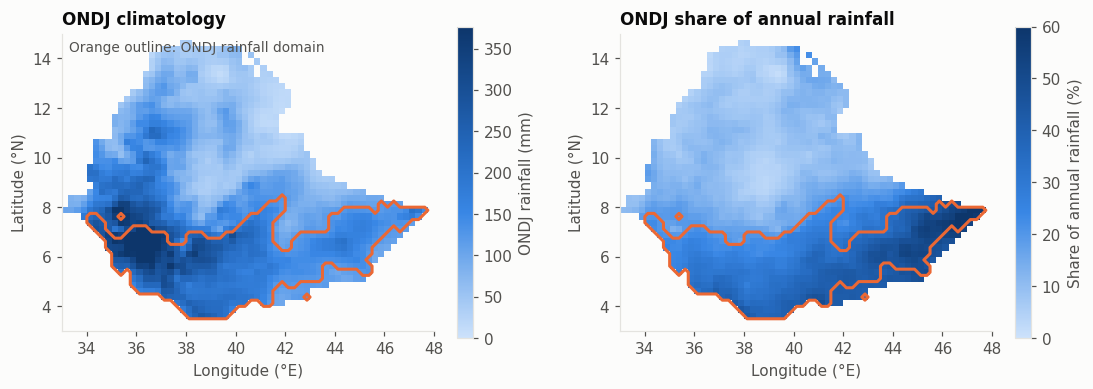

Fixed 1993-2024 descriptive domain: ONDJ climatological CHIRPS rainfall >=120 mm and >=20% of mean annual rainfall (same rule as the JJAS R1+R2 rainfall criteria). The same domain is used for the season and each of its months.
487 cells, 33.0% of Ethiopia


In [12]:
run('python scripts/build_season_domain.py --config config/ondj/project.json', RUN_PIPELINE)
m = xr.open_dataset('data/masks/init09_ONDJ_rainfall_domain.nc')
country = xr.open_dataset('data/masks/ethiopia_common.nc').region_mask
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
clim = m.season_climatology_mm.where(country == 1)
im = axes[0].pcolormesh(m.lon, m.lat, clim, cmap=SEQ, vmin=0, vmax=float(np.nanpercentile(clim, 98)), shading='auto')
fig.colorbar(im, ax=axes[0], shrink=.8, label='ONDJ rainfall (mm)')
share = m.season_share_of_annual.where(country == 1) * 100
im2 = axes[1].pcolormesh(m.lon, m.lat, share, cmap=SEQ, vmin=0, vmax=60, shading='auto')
fig.colorbar(im2, ax=axes[1], shrink=.8, label='Share of annual rainfall (%)')
for ax, title in zip(axes, ['ONDJ climatology', 'ONDJ share of annual rainfall']):
    ax.contour(m.lon, m.lat, m.season_domain, levels=[.5], colors=[ORANGE], linewidths=2)
    map_axes(ax, title)
axes[0].text(33.3, 14.3, 'Orange outline: ONDJ rainfall domain', color=INK2, fontsize=9)
plt.show()
print(m.attrs['domain_definition'])
print(f"{m.attrs['domain_cells']} cells, {m.attrs['domain_country_area_percent']:.1f}% of Ethiopia")

<a id="s10"></a>
## 10. Step 8 — Calibration explained on one grid cell

The final method has three steps, each fitted on the 32 reference seasons only:

1. **Amount correction** per cell, every year weighted equally:
   `x̂ = max(0, μ_obs + r·(x − μ_model))` with `r = clip(σ_obs / σ_model, 0.5, 2)`.
2. **Tercile probabilities**: the share of corrected members below / between / above the CHIRPS terciles,
   smoothed as `(n + 0.5) / (M + 1.5)` so no category is ever 0 or 1.
3. **Climatology blend**: `p = (1 − λ)·p_model + λ·p_clim`, with one λ per target chosen to minimize the
   leave-one-year-out ranked probability score.

The cell below recomputes the chain for the example location and checks the result against the saved forecast.

Cell 5.375°N 39.375°E | CHIRPS mean 208 mm, sd 73 | model mean 195 mm, sd 60 | scale r = 1.21
Terciles q1 = 169 mm, q2 = 212 mm


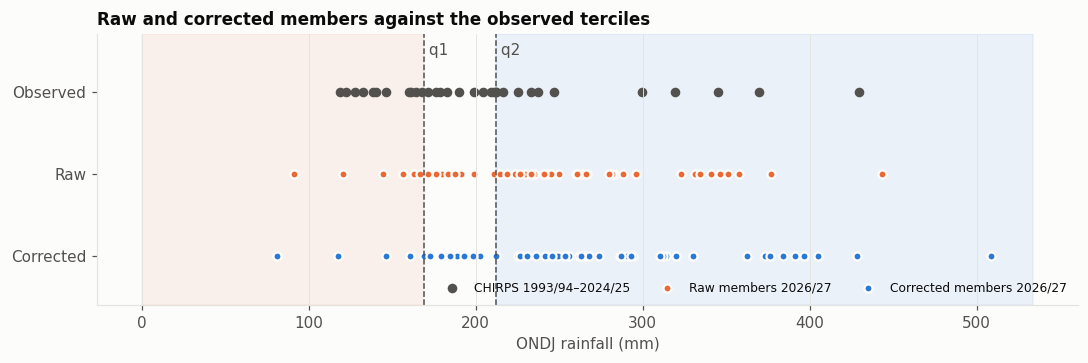

In [13]:
from run_calibration import load_inputs
from calibration_core import fit_amount, correct_amount, probabilities, labels
from compare_calibration import smooth
YEARS = CYCLE.reference_years
tag, models, obsd, members, lat, lon = load_inputs(project, YEARS + [2026], YEARS)
LA, LO = np.meshgrid(lat, lon, indexing='ij')
j = int(np.argmin((LA.ravel() - LAT) ** 2 + (LO.ravel() - LON) ** 2))
pars = fit_amount([models[y] for y in YEARS], np.stack([obsd[y] for y in YEARS]), np.ones(len(lat) * len(lon), bool))
x_raw = models[2026][:, j]
x_cor = correct_amount(models[2026], pars)[:, j]
obs_series = np.array([obsd[y][j] for y in YEARS])
print(f'Cell {LA.ravel()[j]:.3f}°N {LO.ravel()[j]:.3f}°E | CHIRPS mean {pars["mu_obs"][j]:.0f} mm, sd {pars["sd_obs"][j]:.0f} | '
      f'model mean {pars["mu_model"][j]:.0f} mm, sd {pars["sd_model"][j]:.0f} | scale r = {pars["scale"][j]:.2f}')
print(f'Terciles q1 = {pars["q1"][j]:.0f} mm, q2 = {pars["q2"][j]:.0f} mm')

fig, ax = plt.subplots(figsize=(10, 3.4))
ax.axvspan(0, pars['q1'][j], color=ORANGE, alpha=.08); ax.axvspan(pars['q2'][j], max(x_raw.max(), x_cor.max()) * 1.05, color=BLUE, alpha=.08)
ax.scatter(obs_series, np.full(len(obs_series), 2), s=28, color=INK2, label='CHIRPS 1993/94–2024/25')
ax.scatter(x_raw, np.full(len(x_raw), 1), s=28, color=ORANGE, edgecolor=SURFACE, linewidth=1.5, label='Raw members 2026/27')
ax.scatter(x_cor, np.zeros(len(x_cor)), s=28, color=BLUE, edgecolor=SURFACE, linewidth=1.5, label='Corrected members 2026/27')
for q, name in [(pars['q1'][j], 'q1'), (pars['q2'][j], 'q2')]:
    ax.axvline(q, color=INK2, lw=1, ls='--'); ax.text(q, 2.45, f' {name}', color=INK2)
ax.set_yticks([0, 1, 2], ['Corrected', 'Raw', 'Observed']); ax.set_ylim(-.6, 2.7); ax.grid(axis='y', visible=False)
ax.set_xlabel('ONDJ rainfall (mm)'); ax.set_title('Raw and corrected members against the observed terciles', loc='left')
ax.legend(loc='lower right', frameon=False, fontsize=8, ncol=3); plt.tight_layout(); plt.show()

,below,near,above
member counts,9.8,23.5,66.7
smoothed,10.5,23.8,65.7
climatology,34.4,31.2,34.4
blend (λ = 0.28),17.1,25.9,57.0


Matches the saved forecast file: True


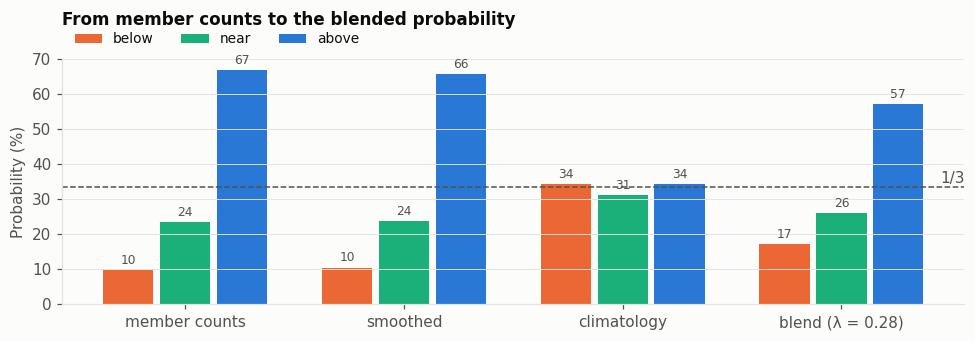

In [14]:
blend_cfg = json.load(open(CYCLE.forecast_dir(CYCLE.root('forecast_root'), 'ONDJ') / 'blend_parameters.json'))
lam = blend_cfg['climatology_weight']
p_counts = probabilities(correct_amount(models[2026], pars), pars)[j]
p_smooth = smooth(p_counts[None], len(x_cor))[0]
cats = np.stack([labels(obsd[y], pars) for y in YEARS])[:, j]
p_clim = np.array([(cats == k).mean() for k in range(3)])
p_blend = (1 - lam) * p_smooth + lam * p_clim
steps = pd.DataFrame([p_counts, p_smooth, p_clim, p_blend], columns=['below', 'near', 'above'],
                     index=['member counts', 'smoothed', 'climatology', f'blend (λ = {lam:.2f})'])
display((steps * 100).round(1))

saved = xr.open_dataset(CYCLE.forecast_file(CYCLE.root('forecast_root'), 'ONDJ')).blend_probability.values.reshape(-1, 3)[j]
print('Matches the saved forecast file:', np.allclose(saved, p_blend, atol=1e-9))

fig, ax = plt.subplots(figsize=(9, 3.2))
xpos = np.arange(len(steps)); width = .26
for k, (cat, colour) in enumerate([('below', ORANGE), ('near', AQUA), ('above', BLUE)]):
    bars = ax.bar(xpos + (k - 1) * width, steps[cat] * 100, width - .03, color=colour, label=cat)
    ax.bar_label(bars, fmt='%.0f', fontsize=8, color=INK2, padding=2)
ax.axhline(100 / 3, color=INK2, lw=1, ls='--'); ax.text(3.45, 34.5, '1/3', color=INK2)
ax.set_xticks(xpos, steps.index); ax.set_ylabel('Probability (%)'); ax.grid(axis='x', visible=False)
ax.set_title('From member counts to the blended probability', loc='left', pad=22)
ax.legend(frameon=False, ncol=3, loc='lower left', bbox_to_anchor=(0, 1.0), fontsize=9)
plt.tight_layout(); plt.show()

<a id="s11"></a>
## 11. Step 9 — Historical skill

Skill is measured with the **ranked probability skill score** (RPSS) against climatology (0 = no better than
climatology). Two evaluations, both with a fixed design chosen before looking at ONDJ:

* **Nested cross-validation 1993–2016**: each year is forecast with parameters fitted without it (clean evidence).
* **Fixed-fit 2017–2024**: parameters from 1993–2016 only, scored on later years.

Each year counts once (a season's correlated grid cells are not independent samples). The p-value is a one-sided
whole-year sign-flip permutation test.

> python scripts/local_blend.py --config config/ondj/project.json --mode training --region-mask data/masks/ethiopia_common.nc
  (not executed: outputs from the recorded run are used below)
> python scripts/run_monthly.py --config config/ondj/project.json --stage training
  (not executed: outputs from the recorded run are used below)
> python scripts/local_blend.py --config config/ondj/project.json --mode operational --region-mask data/masks/ethiopia_common.nc
  (not executed: outputs from the recorded run are used below)
> python scripts/run_monthly.py --config config/ondj/project.json --stage operational
  (not executed: outputs from the recorded run are used below)


period,1993–2016 nested,2017–2024 fixed fit
target,,
Oct,-0.001,0.024
Nov,0.046,0.005
Dec,0.011,0.027
Jan,0.002,0.004
ONDJ,0.020,0.063


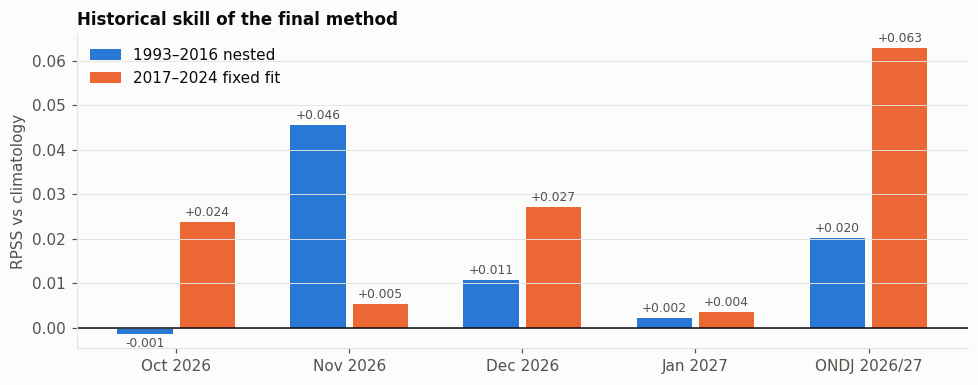

No target is significant at p < 0.05: True


In [15]:
for mode in ['training', 'operational']:
    run(f'python scripts/local_blend.py --config config/ondj/project.json --mode {mode} --region-mask data/masks/ethiopia_common.nc', RUN_PIPELINE)
    run(f'python scripts/run_monthly.py --config config/ondj/project.json --stage {mode}', RUN_PIPELINE)
from significance import paired_summary
rows = []
for t in CYCLE.targets:
    for mode, name in [('training', '1993–2016 nested'), ('operational', '2017–2024 fixed fit')]:
        r = json.load(open(f'outputs/local_calibration/init09_{t}/{mode}/local_comparison_summary.json'))
        b = [y['metrics']['shared_blend']['rps'] for y in r['years']]
        c = [y['metrics']['climatology']['rps'] for y in r['years']]
        s = paired_summary(b, c)
        rows.append(dict(target=t, period=name, RPSS=1 - sum(b) / sum(c), p=s['p_improvement'],
                         years_better=f"{s['years_better']}/{s['years']}"))
skill = pd.DataFrame(rows)
display(skill.pivot(index='target', columns='period', values='RPSS').loc[list(CYCLE.targets)].round(3))

fig, ax = plt.subplots(figsize=(9, 3.6))
xpos = np.arange(len(CYCLE.targets)); width = .36
for k, (period, colour) in enumerate([('1993–2016 nested', BLUE), ('2017–2024 fixed fit', ORANGE)]):
    vals = skill[skill.period == period].set_index('target').loc[list(CYCLE.targets), 'RPSS']
    bars = ax.bar(xpos + (k - .5) * width, vals, width - .04, color=colour, label=period)
    ax.bar_label(bars, labels=[f'{v:+.3f}' for v in vals], fontsize=8, color=INK2, padding=2)
ax.axhline(0, color=INK, lw=1)
ax.set_xticks(xpos, [CYCLE.target_label(t) for t in CYCLE.targets]); ax.set_ylabel('RPSS vs climatology')
ax.grid(axis='x', visible=False); ax.legend(frameon=False); ax.set_title('Historical skill of the final method', loc='left')
plt.tight_layout(); plt.show()
print('No target is significant at p < 0.05:', (skill.p >= .05).all())

<a id="s12"></a>
## 12. Step 10 — Final fit and the 2026/27 forecast

`final_shared_blend.py` refits everything on all 32 reference seasons and applies it to the 51-member
September 2026 forecast. λ (the climatology weight) differs by target: low where the model carries usable
signal (ONDJ, November), high where it does not (January).

In [16]:
run('python scripts/final_shared_blend.py --config config/ondj/project.json --region-mask data/masks/ethiopia_common.nc', RUN_PIPELINE)
rep = json.load(open('outputs/final_shared_blend/final_reports_init09_2026.json'))['reports']
fit = pd.DataFrame([dict(target=r['target_period']['name'], members=r['target_members'], climatology_weight=r['climatology_weight'],
                         probability_cells=r['region_probability_cells'],
                         clipped_member_values=r['fraction_corrected_member_cell_values_clipped']) for r in rep])
display(fit.round(3))

entries = json.load(open('outputs/operational_2026_ondj/entries.json'))['entries']
summary = pd.DataFrame([dict(target=e['target_label'], view=e['label'],
                             below=e['summary']['mean_local_probabilities'][0], near=e['summary']['mean_local_probabilities'][1],
                             above=e['summary']['mean_local_probabilities'][2], anomaly_mm=e['summary']['mean_anomaly_mm'],
                             coverage=e['summary']['probability_domain_area_percent'] / 100) for e in entries])
display(summary.style.format({'below': '{:.0%}', 'near': '{:.0%}', 'above': '{:.0%}', 'anomaly_mm': '{:+.1f}', 'coverage': '{:.0%}'}).hide(axis='index'))

> python scripts/final_shared_blend.py --config config/ondj/project.json --region-mask data/masks/ethiopia_common.nc
  (not executed: outputs from the recorded run are used below)


,target,members,climatology_weight,probability_cells,clipped_member_values
0,Oct,51,0.442,1474,0.045
1,Nov,51,0.231,1459,0.119
2,Dec,51,0.645,924,0.288
3,Jan,51,0.821,952,0.278
4,ONDJ,51,0.279,1478,0.006


target,view,below,near,above,anomaly_mm,coverage
Oct 2026,All Ethiopia,33%,32%,35%,+2.5,99%
Oct 2026,ONDJ rainfall domain,30%,30%,41%,+14.4,100%
Nov 2026,All Ethiopia,26%,26%,48%,+16.7,98%
Nov 2026,ONDJ rainfall domain,20%,22%,58%,+36.4,100%
Dec 2026,All Ethiopia,33%,33%,34%,+2.3,62%
Dec 2026,ONDJ rainfall domain,32%,31%,37%,+5.5,73%
Jan 2027,All Ethiopia,31%,35%,34%,+1.8,64%
Jan 2027,ONDJ rainfall domain,29%,37%,34%,+1.8,55%
ONDJ 2026/27,All Ethiopia,28%,27%,45%,+26.5,100%
ONDJ 2026/27,ONDJ rainfall domain,20%,24%,56%,+64.5,100%


**Reading the result.** Over the ONDJ rainfall domain (south and south-east) the outlook leans towards
**above-normal** rainfall (about 56 % on average), strongest in November; December and January stay close to
climatology. Probabilities are area means of local probabilities, not the probability of the domain total.
Dry-season cells with negligible rainfall have no tercile probabilities, which lowers national coverage in December
and January.

<a id="s13"></a>
## 13. Step 11 — Forecast maps

`build_season_products.py` renders, for each target and both views (All Ethiopia, ONDJ rainfall domain), the
leading-tercile map, corrected mean rainfall and the anomaly in mm and %. The display is smoothed for readability;
statistics use the original 0.25° grid.

> python scripts/build_season_products.py
  (not executed: outputs from the recorded run are used below)


**ONDJ 2026/27 · all ethiopia · tercile outlook**

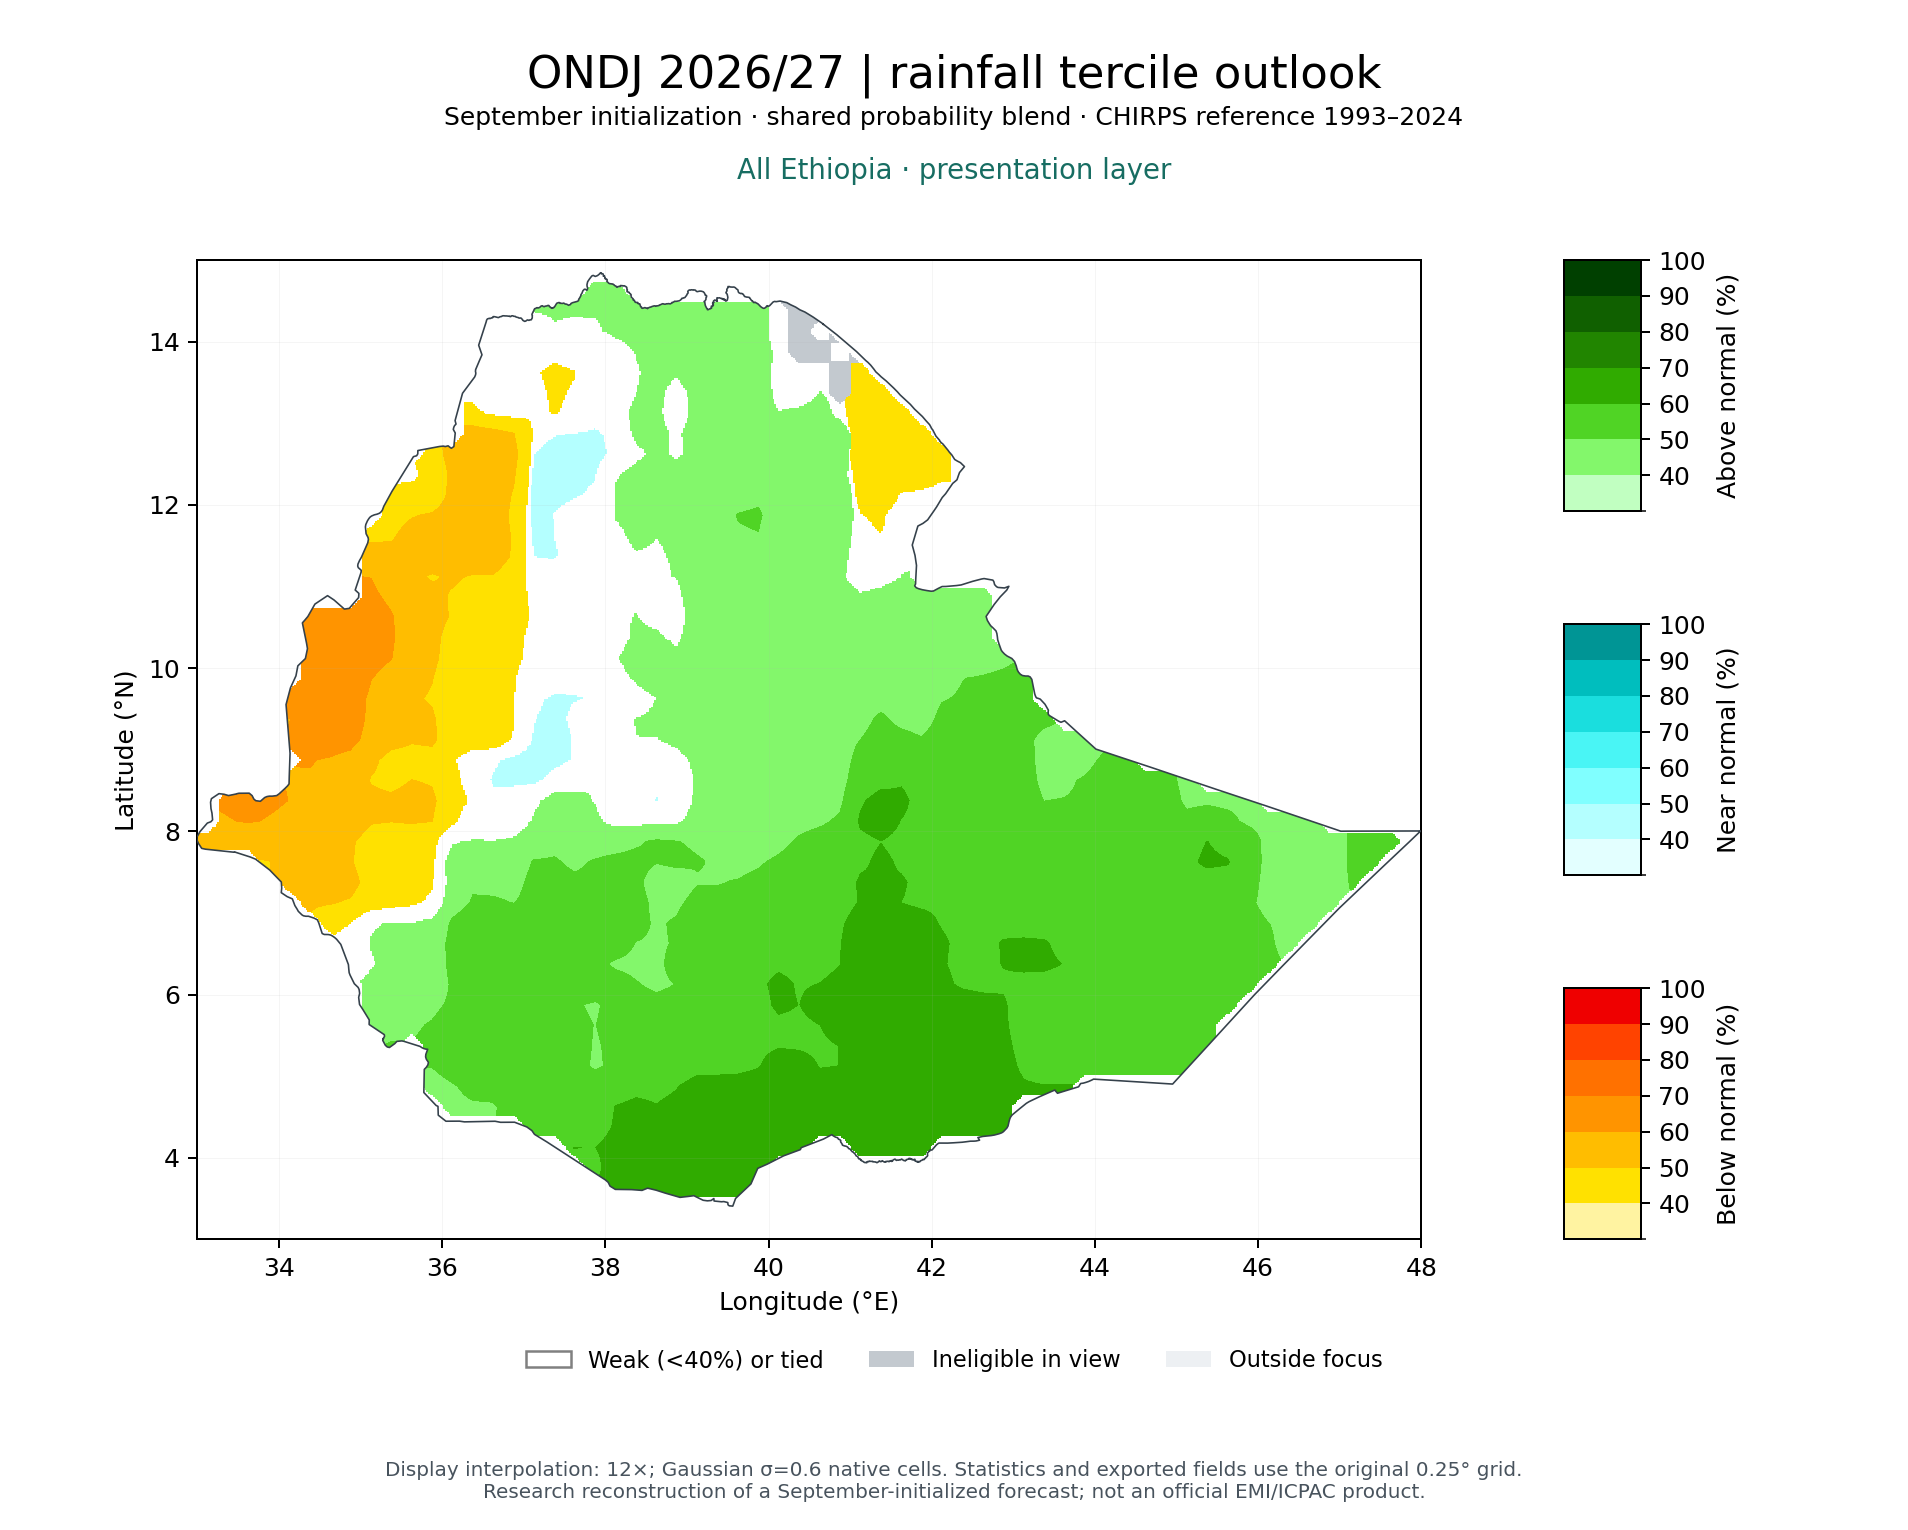

**ONDJ 2026/27 · ondj rainfall domain · tercile outlook**

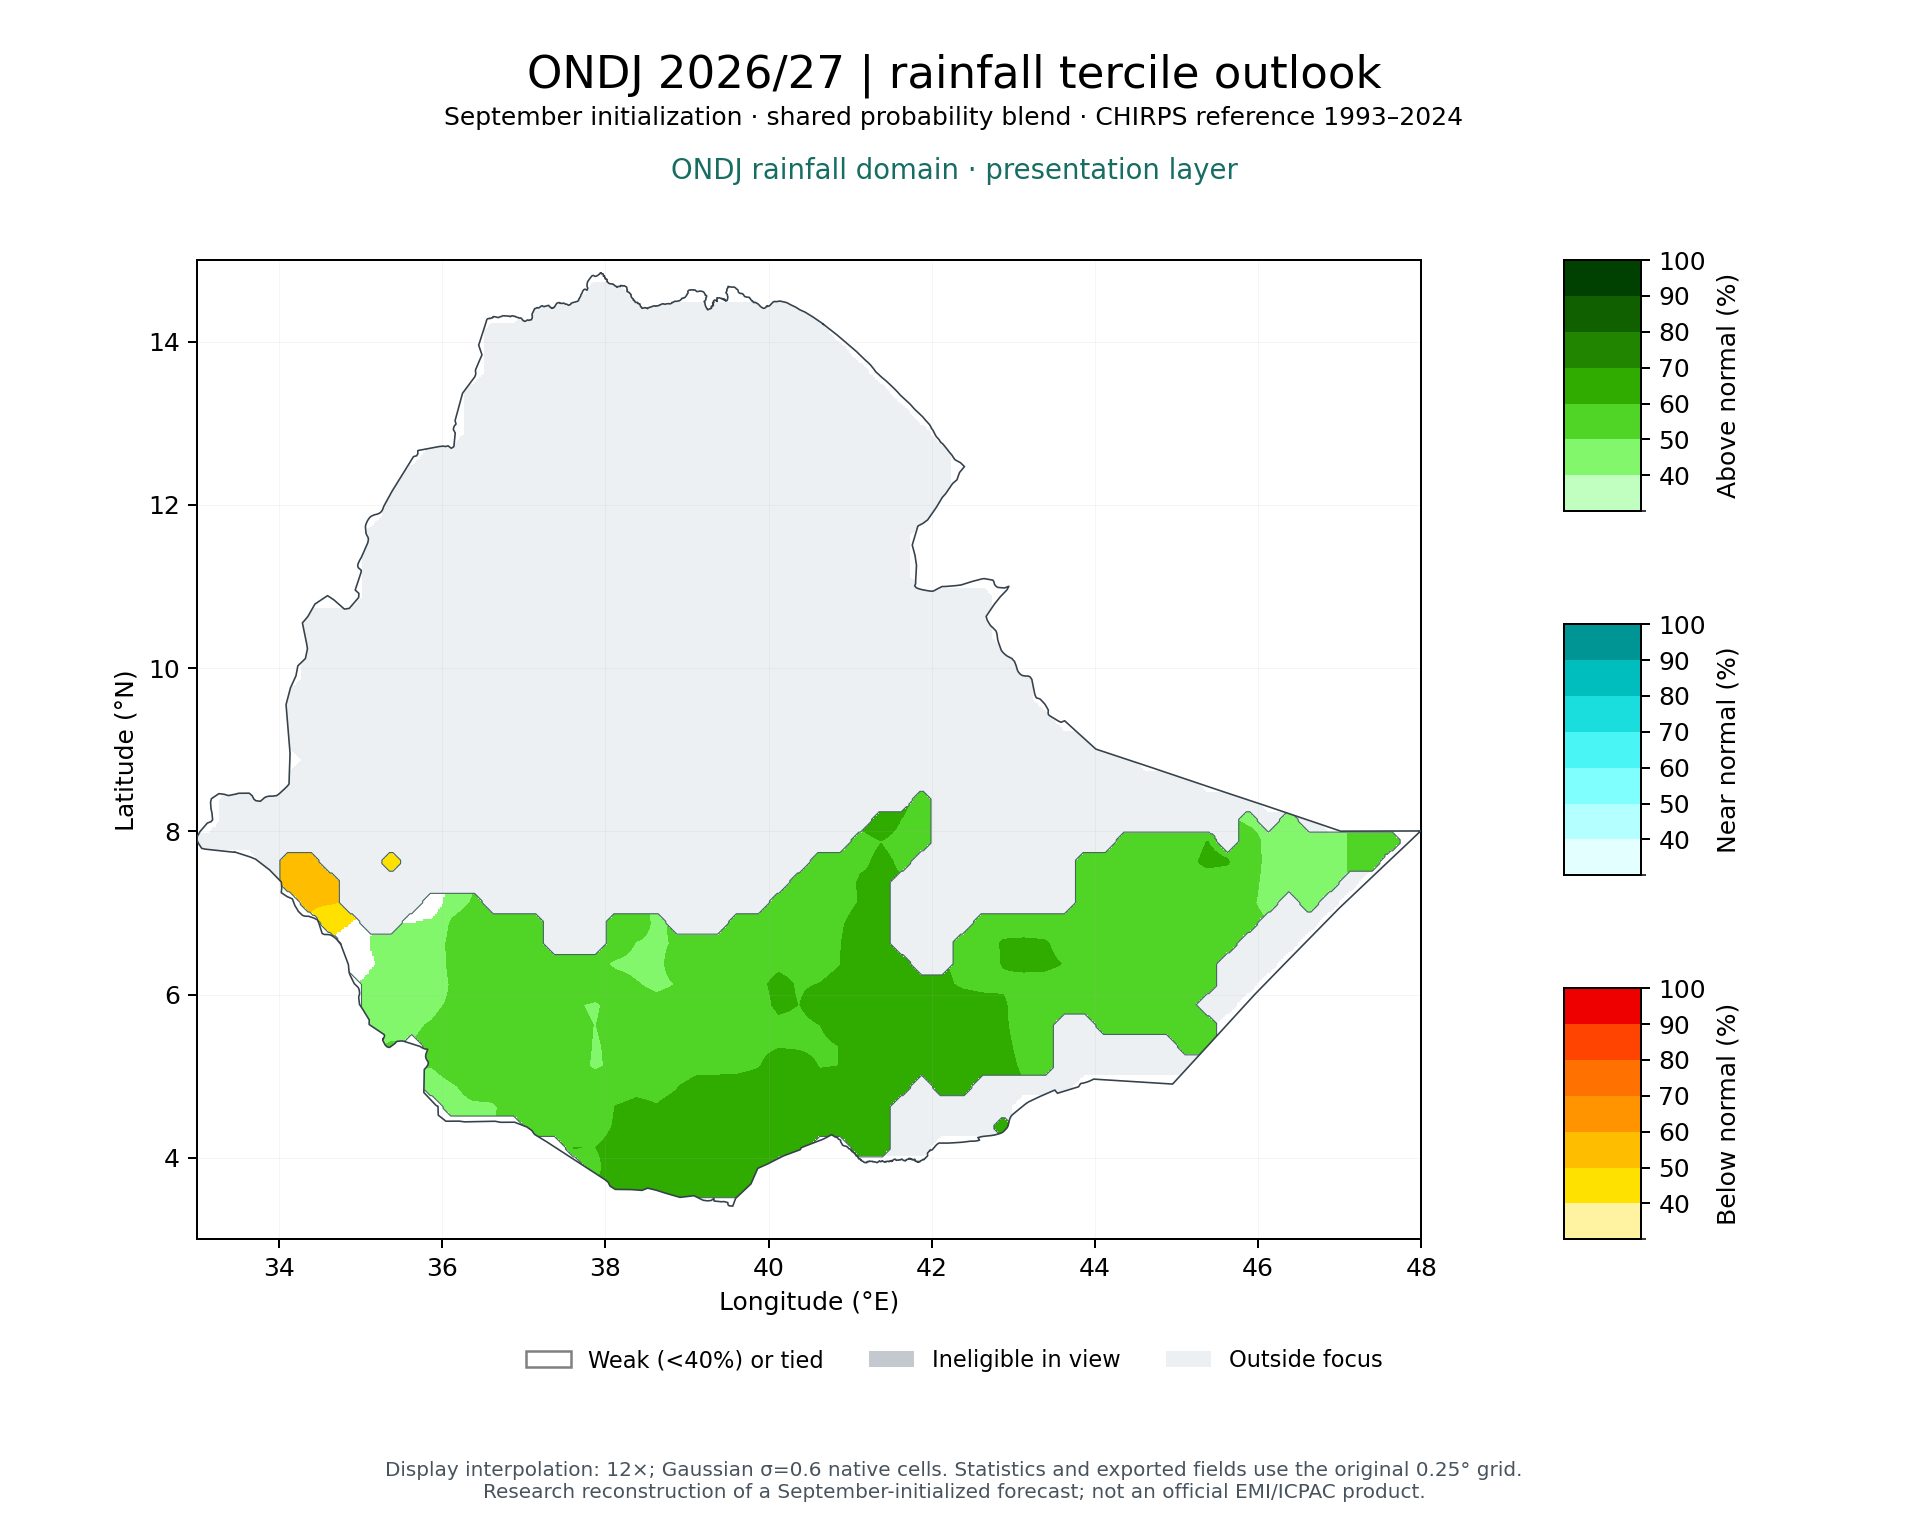

**ONDJ 2026/27 · ondj rainfall domain · rainfall anomaly mm**

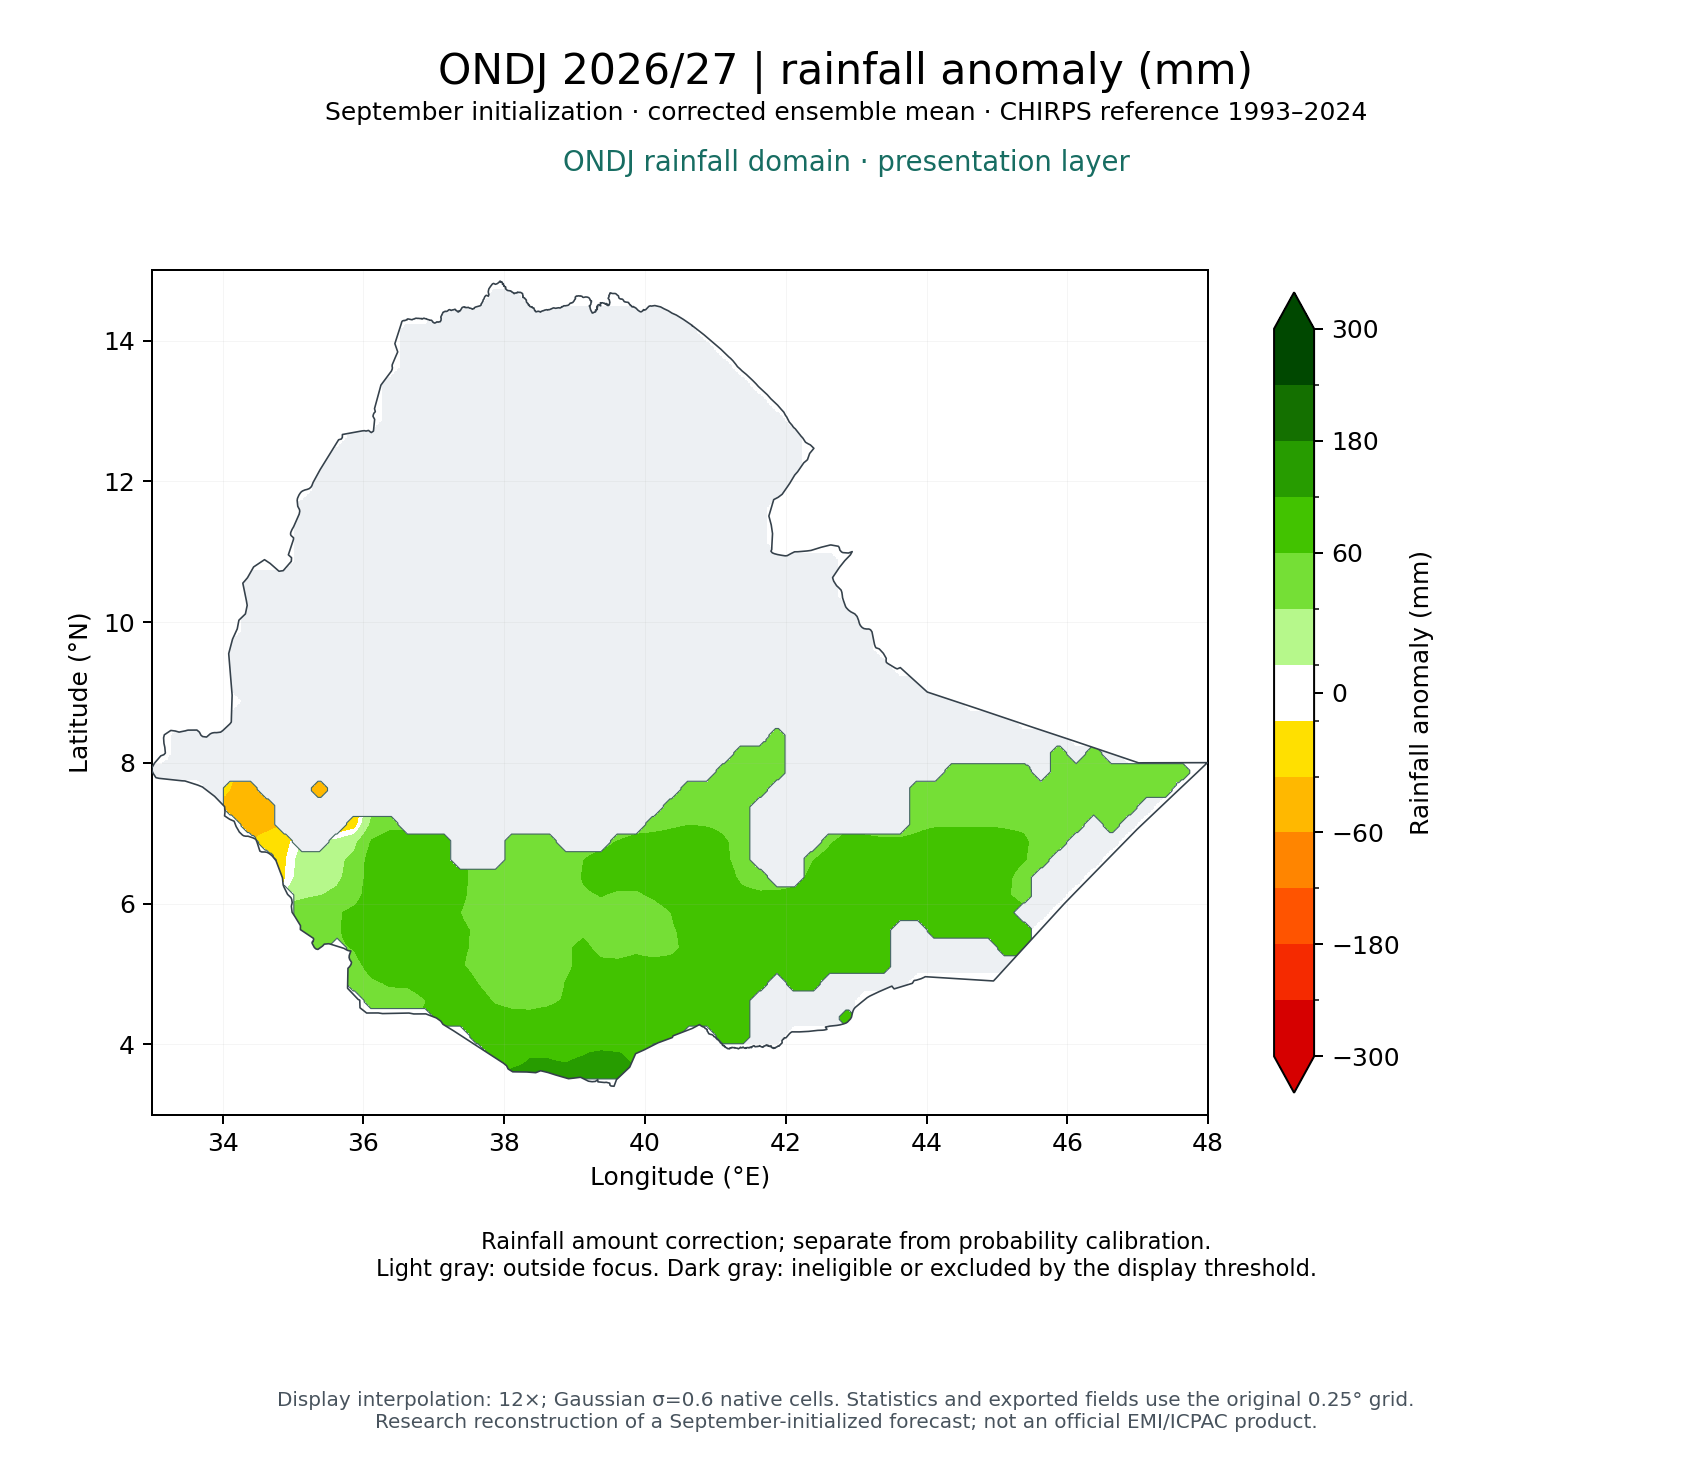

**Nov 2026 · ondj rainfall domain · tercile outlook**

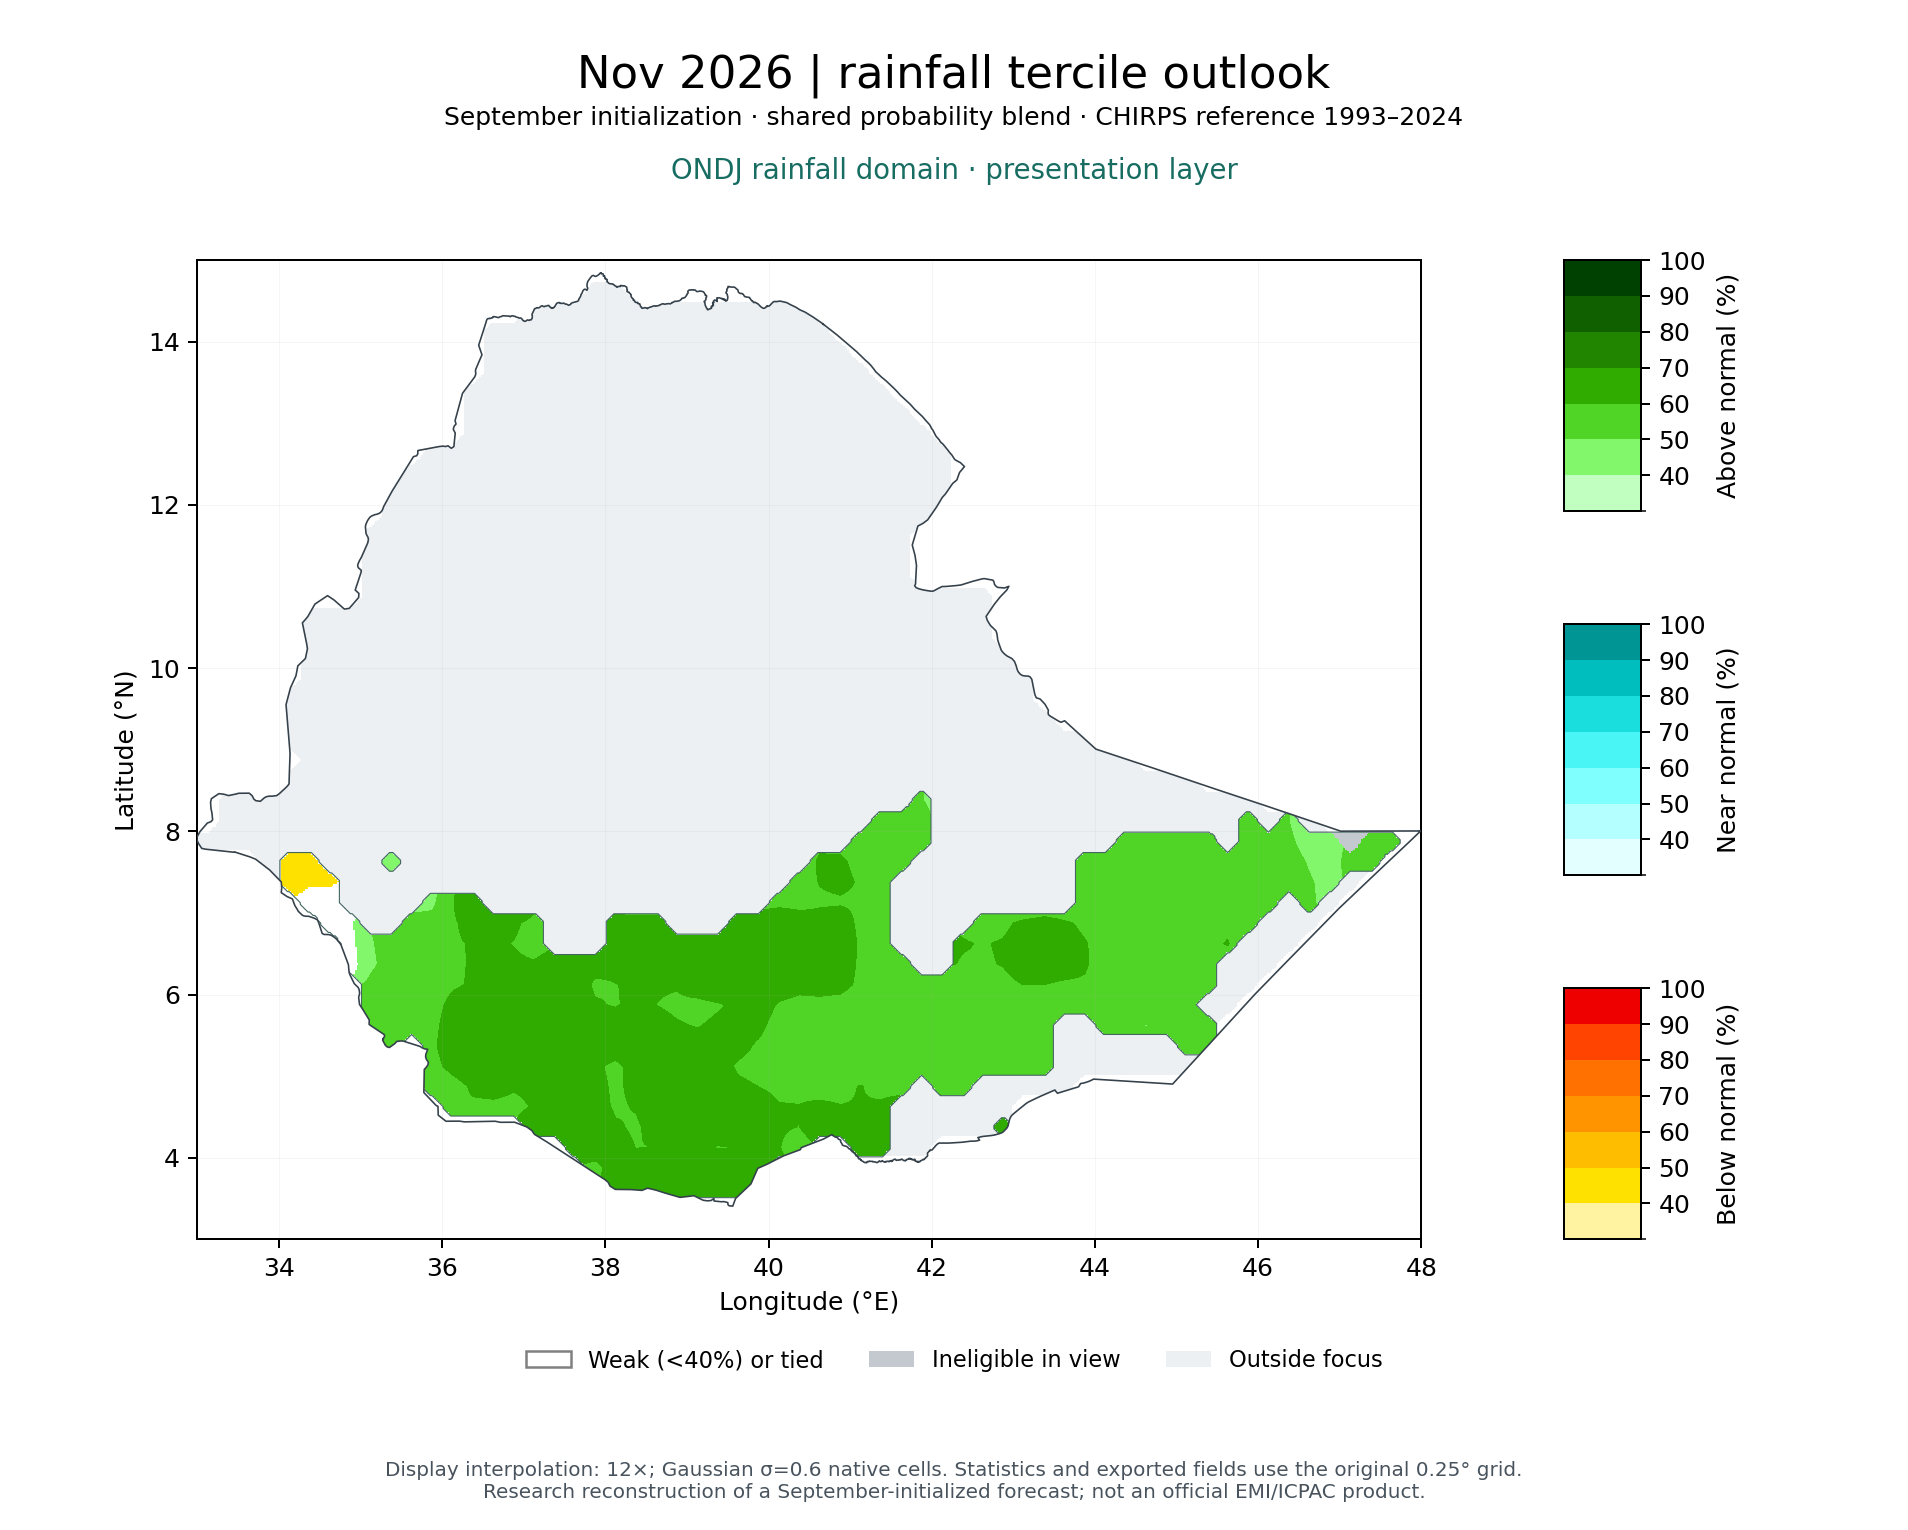

In [17]:
run('python scripts/build_season_products.py', RUN_PIPELINE)
base = Path('outputs/operational_2026_ondj/presentation/forecast')
for target, view, name in [('ONDJ', 'all_ethiopia', 'tercile_outlook'), ('ONDJ', 'ondj_rainfall_domain', 'tercile_outlook'),
                           ('ONDJ', 'ondj_rainfall_domain', 'rainfall_anomaly_mm'), ('Nov', 'ondj_rainfall_domain', 'tercile_outlook')]:
    display(Markdown(f'**{CYCLE.target_label(target)} · {view.replace("_", " ")} · {name.replace("_", " ")}**'))
    display(Image(filename=str(base / target / view / f'{name}.png'), width=760))

<a id="s14"></a>
## 14. Step 12 — Publishing

The results site is generated from the result files and deployed to GitHub Pages by a workflow on every push.
The ONDJ products appear as the group *September initialization · ONDJ 2026/27* in the map explorer.

```bat
python scripts\build_site.py
git add -A
git commit -m "Update ONDJ products"
git push
```

Site: <https://yonsci.github.io/calibrated_seasonal_rainfall/> · Code: <https://github.com/YonSci/calibrated_seasonal_rainfall>

<a id="s15"></a>
## 15. Issues met and lessons

A selection from the issue log in `docs/38_REPRODUCIBLE_RUNBOOK.md`:

| Issue | Cause | Fix / lesson |
| --- | --- | --- |
| "Negative accumulation increments" flagged | GRIB packing rounding (≤ 0.15 mm) | Tolerance 0.2 mm, clip after the telescoping-sum check |
| Seasons crossing 31 December rejected | Calendar assumed one year | `season_window()`; January dated in the next year |
| Downloader crashed on Windows | Console cannot print `→` | `set PYTHONIOENCODING=utf-8` |
| ONDJ run overwrote JJAS summary files | File names keyed on year only | Every summary keyed on the cycle tag (`init09_…`) |
| Hidden "May" assumptions blocked ONDJ maps | Month literals in display code | Use the cycle's initialization month; render a test cycle first |
| Tempting method tweaks looked better on recent years | Years already seen during selection | Pre-registered significance gate on clean 1993–2016 scores |
| Dry-month clipping (Dec–Jan ≈ 28 % of member values) | Additive correction in arid cells | Diagnosed; square-root-space correction planned for amounts |

**Lesson:** after any code change, refit an existing cycle into a scratch folder and compare with the frozen
outputs. Every change in this project was checked this way (exact match).

<a id="s16"></a>
## 16. Exercises

1. **Calendar.** Use `season_window` to find the window of a March–May (MAM) season initialized in February, and of
   a December target initialized in November.
2. **Another cell.** Change `LAT, LON` in sections 4 and 10 to a highland cell (for example 9.0°N, 38.75°E). How do
   the scale factor `r`, the terciles and λ's effect differ? Why does the cell receive few or no probabilities in January?
3. **Skill.** Which target has the largest gap between the two evaluation periods? Why should the 1993–2016 number be
   trusted more?
4. **Domain.** Rebuild the rainfall domain with a 100 mm threshold (edit `MIN_MM` in a copy of
   `build_season_domain.py`). How many cells are added, and where?
5. **New season.** Following `docs/37`, write a project config and cycle file for a February-initialized MAM season.
   Which steps of this notebook change, and which stay the same?

In [18]:
# Exercise 1 starter
mam = {'initialization_month': 2, 'season': {'name': 'MAM', 'start': '03-01', 'end': '05-31'}}
print('MAM from Feb 2027:', season_window(mam, 2027))

MAM from Feb 2027: (datetime.date(2027, 3, 1), datetime.date(2027, 5, 31))


<a id="s17"></a>
## 17. References

* Johnson, S. J. et al. (2019). SEAS5: the new ECMWF seasonal forecast system. *Geosci. Model Dev.* 12, 1087–1117.
* Funk, C. et al. (2015). The climate hazards infrared precipitation with stations (CHIRPS). *Sci. Data* 2, 150066.
* Epstein, E. S. (1969). A scoring system for probability forecasts of ranked categories. *J. Appl. Meteor.* 8, 985–987.
* Project documents: `docs/04` (design), `docs/11` (methods), `docs/36` (status and decisions), `docs/37` (new cycles),
  `docs/38` (runbook, issues, automation).

*Generated by `notebooks/build_ondj_training_notebook.py`. Re-run it after a new cycle to refresh all outputs.*